<a href="https://colab.research.google.com/github/sechan-design/2026-data-science-and-machine-learning/blob/main/ARIMAX_%EB%AA%A8%EB%8D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages("forecast")
library(forecast)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’




In [2]:
data <- read.csv("통합데이터2.csv") #파일명 치기

In [4]:
y <- ts(data$whole)
x1 <- data$whole.popu

x2 <- data$cpi
x_multi <- cbind(x1,x2)

In [5]:
# ARIMAX
model <- auto.arima(y, xreg = x_multi)
summary(model)

Series: y 
Regression with ARIMA(1,0,0) errors 

Coefficients:
         ar1       x1      x2
      0.8714  -0.0018  0.4485
s.e.  0.1010   0.0011  0.0668

sigma^2 = 4.405:  log likelihood = -40.12
AIC=88.25   AICc=91.11   BIC=92.03

Training set error measures:
                     ME    RMSE      MAE       MPE     MAPE      MASE
Training set -0.1660553 1.92594 1.578472 -1.391313 5.172746 0.8934748
                   ACF1
Training set 0.08687281


	Ljung-Box test

data:  Residuals from Regression with ARIMA(1,0,0) errors
Q* = 6.3, df = 3, p-value = 0.09789

Model df: 1.   Total lags used: 4



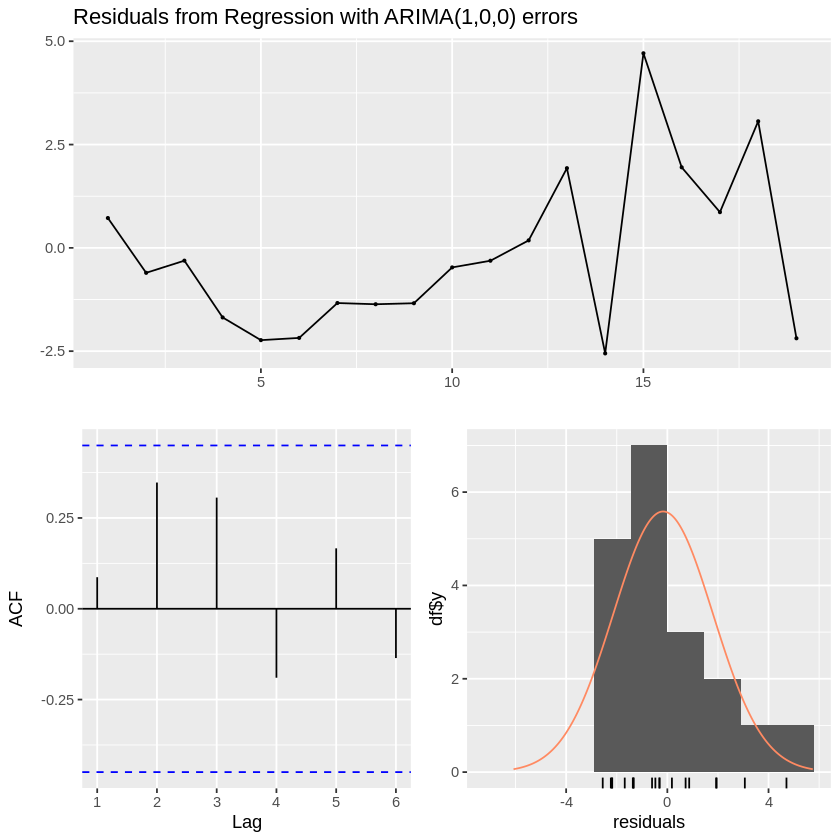

In [6]:
# 잔차 확인
checkresiduals(model)

In [7]:
# 차분 ARIMAX
dy <- diff(y)
dx1 <- diff(x1)
dx2 <- diff(x2)

dx_multi <- cbind(dx1,dx2)

model_diff <- auto.arima(dy, xreg = dx_multi)
summary(model_diff)

Series: dy 
Regression with ARIMA(1,0,0) errors 

Coefficients:
          ar1  intercept     dx1     dx2
      -0.6178     3.1019  0.0154  0.3060
s.e.   0.2083     0.7362  0.0030  0.1887

sigma^2 = 2.361:  log likelihood = -31.25
AIC=72.5   AICc=77.5   BIC=76.95

Training set error measures:
                      ME    RMSE      MAE  MPE MAPE      MASE       ACF1
Training set -0.02588124 1.35513 1.055316 -Inf  Inf 0.5960255 -0.1889968

In [8]:
# 회귀 비교

lm_model <- lm(y ~ x1+x2)
summary(lm_model)


Call:
lm(formula = y ~ x1 + x2)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.9415 -2.2984 -0.1401  2.3794  5.0593 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.198e+02  3.109e+01  -3.854   0.0014 ** 
x1           5.669e-03  2.167e-03   2.616   0.0187 *  
x2           1.184e+00  1.867e-01   6.341  9.8e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.988 on 16 degrees of freedom
Multiple R-squared:  0.8888,	Adjusted R-squared:  0.8749 
F-statistic: 63.94 on 2 and 16 DF,  p-value: 2.338e-08
